# 1.1 — Anatomy of a gas future

> *"Before you can hedge a thing, you must be able to count it."*

## The problem

Monday, 07:40. The overnight risk report from the market-making books says:

> **PEG, Dec-26: +12,400 MWh. TTF, Q1-27: −9,800 MWh.**

Your job is to flatten this on the exchange. Immediately three questions appear that have nothing to do
with statistics and everything to do with *contract mechanics*:

1. Which contract is "Dec-26", and what is its symbol on the screen?
2. How many **lots** is 12,400 MWh? (A lot is not a MWh.)
3. Until *when* can I trade it, and what does one tick cost me?

Get any of these wrong and you either hedge the wrong month, the wrong size, or discover on expiry day
that you are now a physical gas shipper. This chapter makes the mechanics boringly reliable, so that the
rest of the tutorial can be about the interesting part.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style
from gashedge.contracts import *
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch1.1")
log.info("Environment ready")

2026-09-13 16:46:48.749 | INFO    | ch1.1 | Environment ready


## 1. Month codes: the alphabet of the curve

Futures months are written with a single letter followed by a two-digit year. The letters skip the ones
that could be confused with other things (no `I`, no `L`, no `O`), giving the twelve codes below. They
are identical on ICE, CME and EEX — learn them once.

In [2]:
codes = pd.DataFrame({"month": pd.date_range("2026-01-01", periods=12, freq="MS").strftime("%B"),
                      "code": [MONTH_CODES[m] for m in range(1, 13)]})
codes.T

,0,1,2,3,4,5,6,7,8,9,10,11
month,January,February,March,April,May,June,July,August,September,October,November,December
code,F,G,H,J,K,M,N,Q,U,V,X,Z


A symbol is `ROOT + CODE + YY`. For Dutch TTF futures on ICE Endex the root is `TFM`, so December 2026 is
`TFMZ26`. Vendors (Bloomberg, Refinitiv) wrap this differently (`TTFAZ6 Comdty`, `TFMZ6`, ...) but the
month letter is universal.

In [3]:
for (y, m) in [(2026, 12), (2027, 1), (2027, 3)]:
    log.info("%s %d -> %s", codes.month[m - 1], y, contract_symbol(y, m))
parse_symbol("TFMH27")

2026-09-13 16:46:48.758 | INFO    | ch1.1 | December 2026 -> TFMZ26


2026-09-13 16:46:48.758 | INFO    | ch1.1 | January 2027 -> TFMF27


2026-09-13 16:46:48.758 | INFO    | ch1.1 | March 2027 -> TFMH27


('TFM', 2027, 3)

## 2. What one lot actually is

The ICE TTF future is a contract to deliver **1 MW of gas in every hour of the delivery month** at the
virtual trading point. Energy is power × time, so one lot is

$$
\text{lot}_{\text{MWh}} = 1\,\text{MW} \times H_{y,m}
\tag{1.1}
$$

where $H_{y,m}$ is the number of hours in the delivery month. Most months have $24 \times \text{days}$
hours — but the gas day runs 06:00–06:00 **local time**, and Europe changes its clocks in March and
October. March therefore has **743** hours and October **745**. Trivial? A hedging engine that assumes
744 hours for every 31-day month mis-sizes every March and October hedge by one MWh per lot — small per
lot, but systematic, and it makes strip arithmetic (Chapter 1.2) come out wrong by a few cents.
[Appendix B](../appendix/B_delivery_hours_and_strips.ipynb) has the full DST story.

,month,hours,days_x_24,dst_adjustment
2,2026-03,743,744,-1
9,2026-10,745,744,1
14,2027-03,743,744,-1
21,2027-10,745,744,1


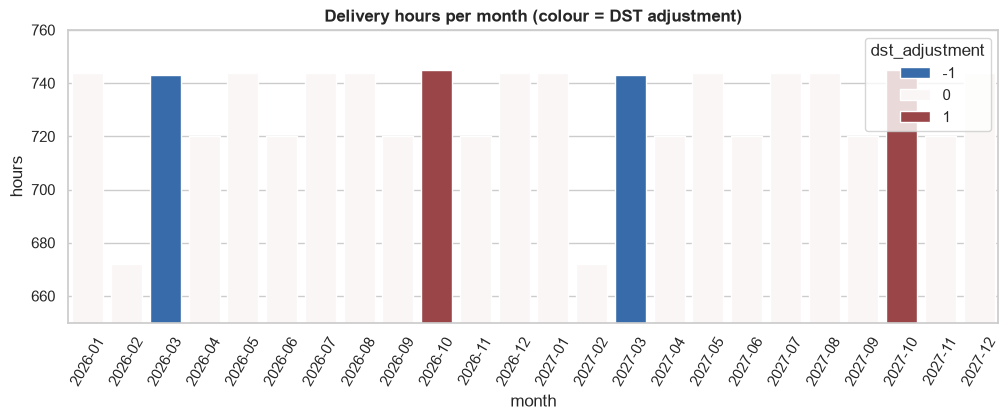

In [4]:
hours = pd.DataFrame({"month": [f"{y}-{m:02d}" for y in (2026, 2027) for m in range(1, 13)],
                      "hours": [delivery_hours(y, m) for y in (2026, 2027) for m in range(1, 13)]})
hours["days_x_24"] = [24 * pd.Period(p).days_in_month for p in hours.month]
hours["dst_adjustment"] = hours.hours - hours.days_x_24
fig, ax = plt.subplots(figsize=(12, 3.8))
sns.barplot(data=hours, x="month", y="hours", hue="dst_adjustment", palette="vlag", ax=ax)
ax.set_ylim(650, 760); ax.set_title("Delivery hours per month (colour = DST adjustment)")
ax.tick_params(axis="x", rotation=60)
hours[hours.dst_adjustment != 0]

Now the risk report line. The exposure is 12,400 MWh in December, which has 744 hours:

$$
n_{\text{lots}} = \frac{Q_{\text{MWh}}}{H_{y,m}} = \frac{12\,400}{744} = 16.67
\tag{1.2}
$$

You cannot trade two-thirds of a lot. Whatever you round to leaves a **residual** of a few hundred MWh —
your first, unavoidable, imperfect hedge. Keep that thought; Module 2 is full of them.

In [5]:
def lots_for(mwh: float, year: int, month: int) -> dict:
    H = delivery_hours(year, month)
    raw = mwh / H
    lots = round(raw)
    return {"symbol": contract_symbol(year, month), "hours": H, "raw_lots": raw,
            "lots": lots, "residual_mwh": mwh - lots * H}

sizing = pd.DataFrame([lots_for(12_400, 2026, 12), lots_for(-9_800 / 3, 2027, 1),
                       lots_for(-9_800 / 3, 2027, 2), lots_for(-9_800 / 3, 2027, 3)])
log.info("Rounding leaves %.0f MWh unhedged across the four lines", sizing.residual_mwh.abs().sum())
sizing

2026-09-13 16:46:48.918 | INFO    | ch1.1 | Rounding leaves 927 MWh unhedged across the four lines


,symbol,hours,raw_lots,lots,residual_mwh
0,TFMZ26,744,16.666667,17,-248.000000
1,TFMF27,744,-4.390681,-4,-290.666667
2,TFMG27,672,-4.861111,-5,93.333333
3,TFMH27,743,-4.396590,-4,-294.666667


(Notice what we quietly did with the Q1-27 line: we split it into three months and assumed the MWh were
spread *equally*. That is wrong — a quarter delivers 1 MW in *every* hour, so its MWh split follows the
hours of each month. Chapter 1.2 does this properly.)

## 3. Ticks, and what a tick is worth

Prices are quoted in EUR/MWh with a minimum increment of €0.005. The EUR value of one tick on one lot is

$$
\text{tick value} = 0.005 \times H_{y,m} \approx €3.72 \ (\text{744 h}),\quad €3.60\ (\text{720 h}),\quad €3.36\ (\text{672 h})
\tag{1.3}
$$

So a 1 EUR/MWh move on a 17-lot December position is $17 \times 744 \times 1 = €12\,648$. When a desk
says "we are long 17 lots of Dec", the risk manager hears "€12.6k per euro".

In [6]:
AS_OF = date(2026, 9, 14)
table = contract_table(AS_OF, n_months=12)
table["tick_value_eur"] = TTF_SPEC.tick_size * table.hours
table["eur_per_1eur_move_x17lots"] = 17 * table.hours
table[["tenor", "symbol", "hours", "tick_value_eur", "eur_per_1eur_move_x17lots", "expiry", "days_to_expiry"]]

,tenor,symbol,hours,tick_value_eur,eur_per_1eur_move_x17lots,expiry,days_to_expiry
0,1,TFMV26,745,3.725,12665,2026-09-29,15
1,2,TFMX26,720,3.600,12240,2026-10-28,44
2,3,TFMZ26,744,3.720,12648,2026-11-27,74
3,4,TFMF27,744,3.720,12648,2026-12-30,107
4,5,TFMG27,672,3.360,11424,2027-01-28,136
5,6,TFMH27,743,3.715,12631,2027-02-25,164
6,7,TFMJ27,720,3.600,12240,2027-03-30,197
7,8,TFMK27,744,3.720,12648,2027-04-28,226
8,9,TFMM27,720,3.600,12240,2027-05-28,256
9,10,TFMN27,744,3.720,12648,2027-06-29,288


## 4. Expiry and delivery — the cliff at the end of the month

A TTF monthly future stops trading **two business days before the first calendar day of the delivery
month** (the exchange's holiday calendar applies; we approximate with weekdays). After that the contract
is *physically* settled: an open long becomes an obligation to take 1 MW every hour of the month at the
hub. A pure financial hedger must therefore be flat — or rolled — before the last trading day.

For the hedging engine this has three consequences:

* The **front month becomes un-tradeable** a couple of days before month-end; your "M1" instrument
  changes identity every month (the *roll*; Chapter 2.4).
* Exposures that live *inside* the delivery month cannot be hedged with that month's future any more;
  they migrate to balance-of-month, day-ahead and within-day products — a different world we leave aside.
* The number of tradable days left on a contract is a risk parameter in its own right (Chapter 1.4).

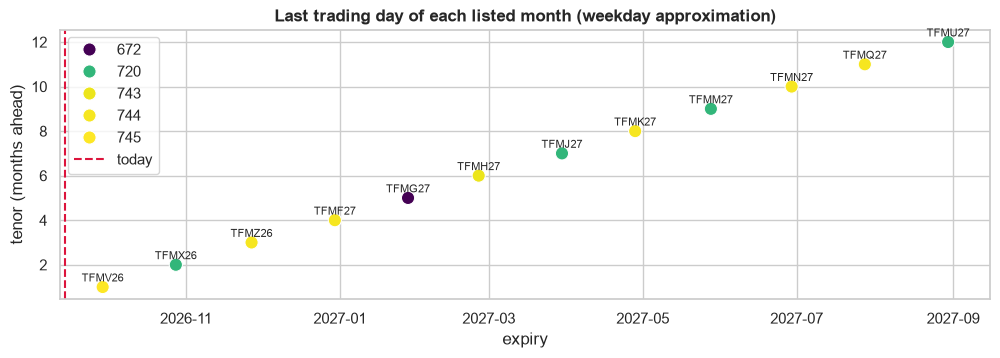

In [7]:
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.scatterplot(data=table, x="expiry", y="tenor", hue="hours", palette="viridis", s=90, ax=ax)
for r in table.itertuples():
    ax.text(r.expiry, r.tenor + 0.25, r.symbol, fontsize=8, ha="center")
ax.axvline(pd.Timestamp(AS_OF), color="crimson", ls="--", label="today")
ax.set_title("Last trading day of each listed month (weekday approximation)"); ax.legend()
ax.set_xlabel("expiry"); ax.set_ylabel("tenor (months ahead)");

## 5. What we have, and what is missing

We can now translate any line of the risk report into `symbol × lots × tick value × expiry`. That is
the *vocabulary*. But the report contained a quarter, and the desk trades seasons and calendar years too.
Those are not separate contracts with their own delivery — they are **strips** that decompose into the
months above, weighted by hours. And the moment we lay all of them side by side we get *the curve*: the
object that hedging is really about.

**Pitfall that leads to the next chapter:** treating a strip as "a contract" rather than "a bundle of
months" mis-sizes every hedge by the DST/hours mismatch and hides which months you are actually exposed
to. Chapter 1.2 fixes this.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** The book is short **50,000 MWh of TTF Mar-27**. How many lots do you buy to flatten it, and what residual (in MWh) is left? Which way would you round if the desk's view is that prices are more likely to rise than fall?

<details><summary><i>Answer 1</i></summary>

March has **743** hours (clocks go forward). $50{,}000 / 743 = 67.29$ lots. Round to **67 lots** → residual short of $50{,}000 - 67 \times 743 = 219$ MWh; round to 68 → residual *long* of 524 MWh. If you fear rising prices you dislike being short, so 68 lots leaves you slightly long; if cost-of-carry or view is neutral, 67 is the smaller absolute residual. Either way, log the residual — it is the seed of Chapter 2.3.

</details>

**Q2.** What is the EUR value of one tick on one lot of the **October** contract, and why is it not the same as for December even though both months have 31 days?

<details><summary><i>Answer 2</i></summary>

October has 745 delivery hours (clocks go *back*, one hour is repeated), so a tick is $0.005 \times 745 = €3.725$ versus $0.005 \times 744 = €3.72$ for December. Same number of days, one extra hour of delivery.

</details>

**Q3.** You are long 100 lots of a Q1-27 strip and short 100 lots each of Jan-27, Feb-27 and Mar-27 monthly futures. What is your net MWh exposure in each month? Explain in one sentence why.

<details><summary><i>Answer 3</i></summary>

**Zero in every month.** One lot of a quarterly strip delivers 1 MW in every hour of the quarter, i.e. exactly 1 MW in every hour of each of its months, so 100 lots of Q1 ≡ 100 lots of Jan + 100 lots of Feb + 100 lots of Mar. Strips are bundles of monthly deliveries, not separate deliveries.

</details>

**Q4.** Compute (by hand, using the rule) the last trading day of `TFMF27`. Then check with `expiry_date(2027, 1)`.

<details><summary><i>Answer 4</i></summary>

Delivery month is January 2027; 1 Jan 2027 is a Friday. Two business days before: Thursday 31 Dec → Wednesday **30 December 2026**. The code agrees (`expiry_date(2027, 1)` → 2026-12-30). In production also check the ICE holiday calendar: if either of those days were an exchange holiday the expiry would move earlier.

</details>


---
◀ [Previous](../00_introduction.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](02_curve_and_strips.ipynb)